### Repli-seq 分析: LR / SVR / RFR / XGBR

In [6]:
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm, trange

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn import preprocessing
from scipy.stats import pearsonr, spearmanr 

import torch

plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [2]:
## total bin pos -- node id
hg38_node2bin = pd.read_table('/data/xujs/Project/DeepLearning/MCIP/Results/preprocess_results/hg38.1000kb.node2bin.txt', header=None, names=['node_id', 'chrom_pos'])
hg38_node2bin['node_id'] = hg38_node2bin['node_id'] - 1

In [4]:
## GM12878 Repli-seq signal.
repli_seq_file = '/data/xujs/Public_Data/Repli-seq/hg38/GM12878/GM12878.Repli-seq.E2L_log2.1Mb.hg38.bedGraph'

df_repli_seq = pd.read_table(repli_seq_file, header=None, names=['chrom', 'start', 'end', 'score'])
df_repli_seq = df_repli_seq.loc[df_repli_seq.score != 0]
df_repli_seq['chrom_pos'] = df_repli_seq['chrom'] + ":" + df_repli_seq['start'].astype(str)

In [6]:
df = pd.merge(df_repli_seq, hg38_node2bin, on='chrom_pos')
df['scale_score'] = preprocessing.scale(df['score'])

emb = np.load(f'/data/xujs/Project/HiC2PoreC/code/SGMCI/results/HiPore-C_GM12878_1Mb/HiPore-C_GM12878_1Mb_test_chr1/HiPore-C_GM12878_1Mb_test_chr1_ND_MIX_Struc_r0.trn_embeddings.npy', allow_pickle=True)

In [7]:
# 划分训练集和测试集

odd_chroms = ['chr1', 'chr3', 'chr5', 'chr7', 'chr9', 'chr11', 'chr13', 'chr15', 'chr17', 'chr19', 'chr21', 'chrX']
even_chroms = ['chr2', 'chr4', 'chr6', 'chr8', 'chr10', 'chr12', 'chr14', 'chr16', 'chr18', 'chr22']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# print(X_train.shape, X_test.shape)

X_train, y_train = emb[df.loc[df.chrom.isin(odd_chroms), 'node_id']], np.array(df.loc[df.chrom.isin(odd_chroms), 'scale_score'].tolist())
X_test, y_test = emb[df.loc[df.chrom.isin(even_chroms), 'node_id']], np.array(df.loc[df.chrom.isin(even_chroms), 'scale_score'].tolist())

In [8]:
#### 1. Random Forest Regressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

param_grid = {
    'n_estimators': [500],
    'max_depth': [25],
}
    
    # 'n_estimators': [100, 300, 500, 700, 900],
    # 'max_depth': [10, 15, 20, 25, 30],
    # 'min_samples_split': [2, 5, 10, 15, 50],
    # 'min_samples_leaf': [1, 2, 5, 10]

# 创建随机森林回归模型
rf = RandomForestRegressor()

grid_search_rf = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_rf.fit(X_train, y_train.ravel())

best_score = -grid_search_rf.best_score_
print(f'Best Cross-Validated Score: {best_score}')

best_params = grid_search_rf.best_params_
print(f'Best Hyperparameters: {best_params}')

best_rf = grid_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

mae_rf = sklearn.metrics.mean_absolute_error(y_test, y_pred_rf)
mse_rf = sklearn.metrics.mean_squared_error(y_test, y_pred_rf)
r2_rf = sklearn.metrics.r2_score(y_test, y_pred_rf)
pearson_r = round(pearsonr(y_test, y_pred_rf)[0], 2)
spearman_r = round(spearmanr(y_test, y_pred_rf)[0], 2)

evaluations_rf_df = pd.DataFrame({
    'Model': ['RF'],
    'MAE': [mae_rf],
    'MSE': [mse_rf],
    'R2': [r2_rf],
    'Pearson_R': [pearson_r],
    'Spearman_R': [spearman_r],
})

print(evaluations_rf_df)

Best Cross-Validated Score: 0.5541425522759887
Best Hyperparameters: {'max_depth': 25, 'n_estimators': 500}
  Model       MAE       MSE        R2  Pearson_R  Spearman_R
0    RF  0.539615  0.455444  0.536612       0.73        0.72


In [18]:
pd.DataFrame({'y_true': y_test, 'y_pred_rf': y_pred_rf}).to_csv('./Repli-Seq_results/rf.pred_result.txt', sep='\t', index=False, header=True)

In [15]:
#### 2. SVR

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

svr = sklearn.svm.SVR()

grid_search_svr = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_svr.fit(X_train, y_train.ravel())

best_score = -grid_search_svr.best_score_
print(f'Best Cross-Validated Score: {best_score}')

best_params = grid_search_svr.best_params_
print(f'Best Hyperparameters: {best_params}')

best_svr = grid_search_svr.best_estimator_

y_pred_svr = best_svr.predict(X_test)

mae_svr = sklearn.metrics.mean_absolute_error(y_test, y_pred_svr)
mse_svr = sklearn.metrics.mean_squared_error(y_test, y_pred_svr)
r2_svr = sklearn.metrics.r2_score(y_test, y_pred_svr)
pearson_r = round(pearsonr(y_test, y_pred_svr)[0], 2)
spearman_r = round(spearmanr(y_test, y_pred_svr)[0], 2)

evaluations_svr_df = pd.DataFrame({
    'Model': ['SVR'],
    'MAE': [mae_svr],
    'MSE': [mse_svr],
    'R2': [r2_svr],
    'Pearson_R': [pearson_r],
    'Spearman_R': [spearman_r],
})

print(evaluations_svr_df)

Best Cross-Validated Score: 0.550888353096017
Best Hyperparameters: {'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}
  Model       MAE       MSE        R2  Pearson_R  Spearman_R
0   SVR  0.521891  0.464391  0.527509       0.73        0.72


In [1]:
#### 3. XGb

import xgboost as xgb

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'n_estimators': [100, 200, 300]
}

xg_reg = xgb.XGBRegressor()

grid_search_xgb = GridSearchCV(xg_reg, param_grid, cv=5, scoring='neg_mean_absolute_error')
grid_search_xgb.fit(X_train, y_train.ravel())

best_score = -grid_search_xgb.best_score_
print(f'Best Cross-Validated Score: {best_score}')

best_params = grid_search_xgb.best_params_
print(f'Best Hyperparameters: {best_params}')

best_xg_reg = grid_search_xgb.best_estimator_

y_pred_xgb = best_xg_reg.predict(X_test)

mae_xgb = sklearn.metrics.mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = sklearn.metrics.mean_squared_error(y_test, y_pred_xgb)
r2_xgb = sklearn.metrics.r2_score(y_test, y_pred_xgb)
pearson_r = round(pearsonr(y_test, y_pred_xgb)[0], 2)
spearman_r = round(spearmanr(y_test, y_pred_xgb)[0], 2)

evaluations_xgb_df = pd.DataFrame({
    'Model': ['XGBoost'],
    'MAE': [mae_xgb],
    'MSE': [mse_xgb],
    'R2': [r2_xgb],
    'Pearson_R': [pearson_r],
    'Spearman_R': [spearman_r],
})

print(evaluations_xgb_df)

In [ ]:
#### 4. SGD

from sklearn.linear_model import SGDRegressor

param_grid = {
    'loss': ['squared_epsilon_insensitive', 'huber', 'epsilon_insensitive'],
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive']
}

sgd = SGDRegressor(max_iter=5000)

grid_search_sgd = GridSearchCV(sgd, param_grid, cv=5, scoring='neg_mean_absolute_error')
grid_search_sgd.fit(X_train, y_train.ravel())

best_score = -grid_search_sgd.best_score_
print(f'Best Cross-Validated Score: {best_score}')

best_params = grid_search_sgd.best_params_
print(f'Best Hyperparameters: {best_params}')

best_sgd = grid_search_sgd.best_estimator_

y_pred_sgd = best_sgd.predict(X_test)

mae_sgd = sklearn.metrics.mean_absolute_error(y_test, y_pred_sgd)
mse_sgd = sklearn.metrics.mean_squared_error(y_test, y_pred_sgd)
r2_sgd = sklearn.metrics.r2_score(y_test, y_pred_sgd)
pearson_r = round(pearsonr(y_test, y_pred_sgd)[0], 2)
spearman_r = round(spearmanr(y_test, y_pred_sgd)[0], 2)

evaluations_sgd_df = pd.DataFrame({
    'Model': ['SGDRegressor'],
    'MAE': [mae_sgd],
    'MSE': [mse_sgd],
    'R2': [r2_sgd],
    'Pearson_R': [pearson_r],
    'Spearman_R': [spearman_r],
})

print(evaluations_sgd_df)

/data/xujs/miniconda3/envs/GLASS/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1561: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/data/xujs/miniconda3/envs/GLASS/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1561: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/data/xujs/miniconda3/envs/GLASS/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1561: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/data/xujs/miniconda3/envs/GLASS/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1561: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
 

Best Cross-Validated Score: 0.5918447559750574
Best Hyperparameters: {'alpha': 0.0001, 'learning_rate': 'invscaling', 'loss': 'epsilon_insensitive', 'penalty': 'l2'}
          Model       MAE       MSE        R2  Pearson_R  Spearman_R
0  SGDRegressor  0.558099  0.491582  0.499844       0.71        0.72


In [ ]:
#### 5. LR
from sklearn.linear_model import LinearRegression

param_grid = {
    'fit_intercept': [True, False],
    'copy_X': [True, False],
}

lr = LinearRegression()

grid_search_lm = GridSearchCV(lr, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_lm.fit(X_train, y_train.ravel())

best_score = -grid_search_lm.best_score_
print(f'Best Cross-Validated Score: {best_score}')

best_params = grid_search_lm.best_params_
print(f'Best Hyperparameters: {best_params}')

best_lr = grid_search_lm.best_estimator_

y_pred_lr = best_lr.predict(X_test)

mae_lr = sklearn.metrics.mean_absolute_error(y_test, y_pred_lr)
mse_lr = sklearn.metrics.mean_squared_error(y_test, y_pred_lr)
r2_lr = sklearn.metrics.r2_score(y_test, y_pred_lr)
pearson_r = round(pearsonr(y_test, y_pred_lr)[0], 2)
spearman_r = round(spearmanr(y_test, y_pred_lr)[0], 2)

evaluations_lr_df = pd.DataFrame({
    'Model': ['LinearRegression'],
    'MAE': [mae_lr],
    'MSE': [mse_lr],
    'R2': [r2_lr],
    'Pearson_R': [pearson_r],
    'Spearman_R': [spearman_r],
})

print(evaluations_lr_df)

Best Cross-Validated Score: 0.6758574906739704
Best Hyperparameters: {'copy_X': True, 'fit_intercept': False}
              Model       MAE       MSE       R2  Pearson_R  Spearman_R
0  LinearRegression  0.584036  0.518349  0.47261       0.69         0.7


In [127]:
pd.concat([evaluations_lr_df,
            evaluations_rf_df,
            evaluations_svr_df,
            evaluations_sgd_df,
            evaluations_xgb_df])

,Model,MAE,MSE,R2,Pearson_R,Spearman_R
0,LinearRegression,0.584036,0.518349,0.472610,0.69,0.70
0,RF,0.540489,0.458461,0.533542,0.73,0.72
0,SVR,0.521891,0.464391,0.527509,0.73,0.72
0,SGDRegressor,0.558099,0.491582,0.499844,0.71,0.72
0,XGBoost,0.541588,0.478450,0.513205,0.72,0.70


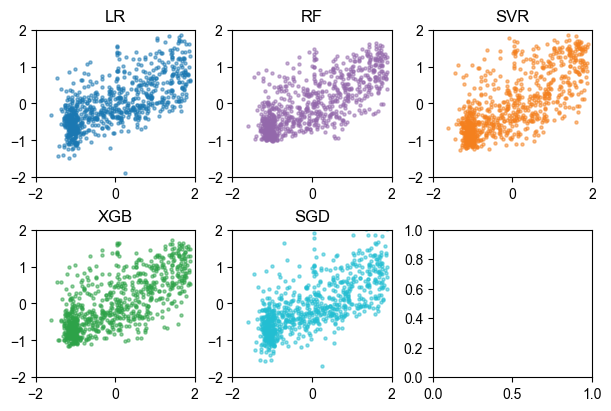

In [131]:
fig, axes = plt.subplots(2, 3, figsize=(6, 4), constrained_layout=True)
axes = axes.flatten()

axes[0].scatter(x=y_test, y=y_pred_lr, alpha=0.5, s=5, c='#1b78b2')
axes[1].scatter(x=y_test, y=y_pred_rf, alpha=0.5, s=5, c='#9368ab')
axes[2].scatter(x=y_test, y=y_pred_svr, alpha=0.5, s=5, c='#f4801e')
axes[3].scatter(x=y_test, y=y_pred_xgb, alpha=0.5, s=5, c='#2da248')
axes[4].scatter(x=y_test, y=y_pred_sgd, alpha=0.5, s=5, c='#22bed2')

axes[0].set_title('LR')
axes[1].set_title('RF')
axes[2].set_title('SVR')
axes[3].set_title('XGB')
axes[4].set_title('SGD')

# axes[0].set_title('PCA')
# axes[0].legend_.remove()

for i in range(5):
    axes[i].set_xlim(-2, 2)
    axes[i].set_ylim(-2, 2)

fig.savefig('./Repli_Seq.Predict_True.scatter_plot.pdf')


In [ ]:
## save model

import pickle

file = open('random_forest_regression_model.pt', 'wb')

pickle.dump(rf_random, file)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(6, 4), constrained_layout=True)
axes = axes.flatten()

axes[0].scatter(x=y_test, y=y_pred_lr, alpha=0.5, s=5, c='#1b78b2')
axes[1].scatter(x=y_test, y=y_pred_rf, alpha=0.5, s=5, c='#9368ab')
axes[2].scatter(x=y_test, y=y_pred_svr, alpha=0.5, s=5, c='#f4801e')
axes[3].scatter(x=y_test, y=y_pred_xgb, alpha=0.5, s=5, c='#2da248')
axes[4].scatter(x=y_test, y=y_pred_sgd, alpha=0.5, s=5, c='#22bed2')

axes[0].set_title('LR')
axes[1].set_title('RF')
axes[2].set_title('SVR')
axes[3].set_title('XGB')
axes[4].set_title('SGD')

# axes[0].set_title('PCA')
# axes[0].legend_.remove()

for i in range(5):
    axes[i].set_xlim(-2, 2)
    axes[i].set_ylim(-2, 2)

# fig.savefig('./Repli_Seq.Predict_True.scatter_plot.pdf')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

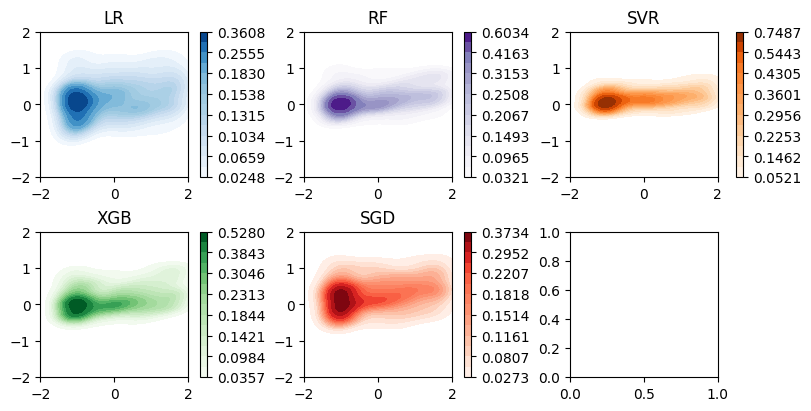

In [19]:
### 2024.06.25 决定还是用散点图，未画完如下的散点密度图

import seaborn as sns  

fig, axes = plt.subplots(2, 3, figsize=(8, 4), constrained_layout=True)
axes = axes.flatten()

# sns.kdeplot(x=y_test, y=y_pred_rf, cmap='Spectral', cbar=True, shade=True, shade_lowest=True)
sns.kdeplot(x=y_test, y=y_pred_lr, cmap='Blues', cbar=True, fill=True, thresh=0.05, n_levels=15, ax=axes[0])
sns.kdeplot(x=y_test, y=y_pred_rf, cmap='Purples', cbar=True, fill=True, thresh=0.05, n_levels=15, ax=axes[1])
sns.kdeplot(x=y_test, y=y_pred_svr, cmap='Oranges', cbar=True, fill=True, thresh=0.05, n_levels=15, ax=axes[2])
sns.kdeplot(x=y_test, y=y_pred_xgb, cmap='Greens', cbar=True, fill=True, thresh=0.05, n_levels=15, ax=axes[3])
sns.kdeplot(x=y_test, y=y_pred_sgd, cmap='Reds', cbar=True, fill=True, thresh=0.05, n_levels=15, ax=axes[4])

axes[0].set_title('LR')
axes[1].set_title('RF')
axes[2].set_title('SVR')
axes[3].set_title('XGB')
axes[4].set_title('SGD')

for i in range(5):
    axes[i].set_xlim(-2, 2)
    axes[i].set_ylim(-2, 2)


### 2026-08-20 补充GAE embedding预测结果

In [7]:
### GAE embedding.
## total bin pos -- node id
hg38_node2bin = pd.read_table('/data/xujs/Project/DeepLearning/MCIP/Results/preprocess_results/hg38.1000kb.node2bin.txt', header=None, names=['node_id', 'chrom_pos'])
hg38_node2bin['node_id'] = hg38_node2bin['node_id'] - 1

## GM12878 Repli-seq signal.
repli_seq_file = '/data/xujs/Public_Data/Repli-seq/hg38/GM12878/4DN/GM12878.Repli-seq.E2L_log2.1Mb.hg38.bedGraph'

df_repli_seq = pd.read_table(repli_seq_file, header=None, names=['chrom', 'start', 'end', 'score'])
df_repli_seq = df_repli_seq.loc[df_repli_seq.score != 0]
df_repli_seq['chrom_pos'] = df_repli_seq['chrom'] + ":" + df_repli_seq['start'].astype(str)

df = pd.merge(df_repli_seq, hg38_node2bin, on='chrom_pos')
df['scale_score'] = preprocessing.scale(df['score'])

emb = torch.load(f"/data/xujs/Project/HiC2PoreC/code/SGMCI/Emb/HiPore-C_GM12878_1Mb_64.pt", map_location=torch.device('cpu')).detach().cpu().numpy()

In [9]:
# 划分训练集和测试集

odd_chroms = ['chr1', 'chr3', 'chr5', 'chr7', 'chr9', 'chr11', 'chr13', 'chr15', 'chr17', 'chr19', 'chr21', 'chrX']
even_chroms = ['chr2', 'chr4', 'chr6', 'chr8', 'chr10', 'chr12', 'chr14', 'chr16', 'chr18', 'chr22']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# print(X_train.shape, X_test.shape)

X_train, y_train = emb[df.loc[df.chrom.isin(odd_chroms), 'node_id']], np.array(df.loc[df.chrom.isin(odd_chroms), 'scale_score'].tolist())
X_test, y_test = emb[df.loc[df.chrom.isin(even_chroms), 'node_id']], np.array(df.loc[df.chrom.isin(even_chroms), 'scale_score'].tolist())

In [10]:
#### 1. Random Forest Regressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

param_grid = {
    'n_estimators': [500],
    'max_depth': [25],
}
    
    # 'n_estimators': [100, 300, 500, 700, 900],
    # 'max_depth': [10, 15, 20, 25, 30],
    # 'min_samples_split': [2, 5, 10, 15, 50],
    # 'min_samples_leaf': [1, 2, 5, 10]

# 创建随机森林回归模型
rf = RandomForestRegressor()

grid_search_rf = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_rf.fit(X_train, y_train.ravel())

best_score = -grid_search_rf.best_score_
print(f'Best Cross-Validated Score: {best_score}')

best_params = grid_search_rf.best_params_
print(f'Best Hyperparameters: {best_params}')

best_rf = grid_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

mae_rf = sklearn.metrics.mean_absolute_error(y_test, y_pred_rf)
mse_rf = sklearn.metrics.mean_squared_error(y_test, y_pred_rf)
r2_rf = sklearn.metrics.r2_score(y_test, y_pred_rf)
pearson_r = round(pearsonr(y_test, y_pred_rf)[0], 2)
spearman_r = round(spearmanr(y_test, y_pred_rf)[0], 2)

evaluations_rf_df = pd.DataFrame({
    'Model': ['RF'],
    'MAE': [mae_rf],
    'MSE': [mse_rf],
    'R2': [r2_rf],
    'Pearson_R': [pearson_r],
    'Spearman_R': [spearman_r],
})

print(evaluations_rf_df)

Best Cross-Validated Score: 0.9142749104243597
Best Hyperparameters: {'max_depth': 25, 'n_estimators': 500}
  Model      MAE       MSE        R2  Pearson_R  Spearman_R
0    RF  0.84741  0.965985  0.017166       0.28        0.27


In [11]:
#### 2. SVR

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

svr = sklearn.svm.SVR()

grid_search_svr = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_svr.fit(X_train, y_train.ravel())

best_score = -grid_search_svr.best_score_
print(f'Best Cross-Validated Score: {best_score}')

best_params = grid_search_svr.best_params_
print(f'Best Hyperparameters: {best_params}')

best_svr = grid_search_svr.best_estimator_

y_pred_svr = best_svr.predict(X_test)

mae_svr = sklearn.metrics.mean_absolute_error(y_test, y_pred_svr)
mse_svr = sklearn.metrics.mean_squared_error(y_test, y_pred_svr)
r2_svr = sklearn.metrics.r2_score(y_test, y_pred_svr)
pearson_r = round(pearsonr(y_test, y_pred_svr)[0], 2)
spearman_r = round(spearmanr(y_test, y_pred_svr)[0], 2)

evaluations_svr_df = pd.DataFrame({
    'Model': ['SVR'],
    'MAE': [mae_svr],
    'MSE': [mse_svr],
    'R2': [r2_svr],
    'Pearson_R': [pearson_r],
    'Spearman_R': [spearman_r],
})

print(evaluations_svr_df)

Best Cross-Validated Score: 0.8883026634473792
Best Hyperparameters: {'C': 1, 'epsilon': 1, 'kernel': 'rbf'}
  Model       MAE       MSE        R2  Pearson_R  Spearman_R
0   SVR  0.870102  0.979645  0.003268       0.24        0.22


In [12]:
#### 3. XGb

import xgboost as xgb

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'n_estimators': [100, 200, 300]
}

xg_reg = xgb.XGBRegressor()

grid_search_xgb = GridSearchCV(xg_reg, param_grid, cv=5, scoring='neg_mean_absolute_error')
grid_search_xgb.fit(X_train, y_train.ravel())

best_score = -grid_search_xgb.best_score_
print(f'Best Cross-Validated Score: {best_score}')

best_params = grid_search_xgb.best_params_
print(f'Best Hyperparameters: {best_params}')

best_xg_reg = grid_search_xgb.best_estimator_

y_pred_xgb = best_xg_reg.predict(X_test)

mae_xgb = sklearn.metrics.mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = sklearn.metrics.mean_squared_error(y_test, y_pred_xgb)
r2_xgb = sklearn.metrics.r2_score(y_test, y_pred_xgb)
pearson_r = round(pearsonr(y_test, y_pred_xgb)[0], 2)
spearman_r = round(spearmanr(y_test, y_pred_xgb)[0], 2)

evaluations_xgb_df = pd.DataFrame({
    'Model': ['XGBoost'],
    'MAE': [mae_xgb],
    'MSE': [mse_xgb],
    'R2': [r2_xgb],
    'Pearson_R': [pearson_r],
    'Spearman_R': [spearman_r],
})

print(evaluations_xgb_df)

Best Cross-Validated Score: 0.8277090323493429
Best Hyperparameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300}
     Model       MAE       MSE      R2  Pearson_R  Spearman_R
0  XGBoost  0.844233  0.968212  0.0149       0.27        0.24


In [13]:
#### 4. SGD

from sklearn.linear_model import SGDRegressor

param_grid = {
    'loss': ['squared_epsilon_insensitive', 'huber', 'epsilon_insensitive'],
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive']
}

sgd = SGDRegressor(max_iter=5000)

grid_search_sgd = GridSearchCV(sgd, param_grid, cv=5, scoring='neg_mean_absolute_error')
grid_search_sgd.fit(X_train, y_train.ravel())

best_score = -grid_search_sgd.best_score_
print(f'Best Cross-Validated Score: {best_score}')

best_params = grid_search_sgd.best_params_
print(f'Best Hyperparameters: {best_params}')

best_sgd = grid_search_sgd.best_estimator_

y_pred_sgd = best_sgd.predict(X_test)

mae_sgd = sklearn.metrics.mean_absolute_error(y_test, y_pred_sgd)
mse_sgd = sklearn.metrics.mean_squared_error(y_test, y_pred_sgd)
r2_sgd = sklearn.metrics.r2_score(y_test, y_pred_sgd)
pearson_r = round(pearsonr(y_test, y_pred_sgd)[0], 2)
spearman_r = round(spearmanr(y_test, y_pred_sgd)[0], 2)

evaluations_sgd_df = pd.DataFrame({
    'Model': ['SGDRegressor'],
    'MAE': [mae_sgd],
    'MSE': [mse_sgd],
    'R2': [r2_sgd],
    'Pearson_R': [pearson_r],
    'Spearman_R': [spearman_r],
})

print(evaluations_sgd_df)

/data/xujs/miniconda3/envs/GLASS/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1561: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/data/xujs/miniconda3/envs/GLASS/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1561: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/data/xujs/miniconda3/envs/GLASS/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1561: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/data/xujs/miniconda3/envs/GLASS/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1561: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
 

Best Cross-Validated Score: 0.7923390260980842
Best Hyperparameters: {'alpha': 0.0001, 'learning_rate': 'constant', 'loss': 'huber', 'penalty': None}
          Model       MAE       MSE        R2  Pearson_R  Spearman_R
0  SGDRegressor  0.905885  1.120305 -0.139845       0.21         0.2


In [14]:
#### 5. LR
from sklearn.linear_model import LinearRegression

param_grid = {
    'fit_intercept': [True, False],
    'copy_X': [True, False],
}

lr = LinearRegression()

grid_search_lm = GridSearchCV(lr, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_lm.fit(X_train, y_train.ravel())

best_score = -grid_search_lm.best_score_
print(f'Best Cross-Validated Score: {best_score}')

best_params = grid_search_lm.best_params_
print(f'Best Hyperparameters: {best_params}')

best_lr = grid_search_lm.best_estimator_

y_pred_lr = best_lr.predict(X_test)

mae_lr = sklearn.metrics.mean_absolute_error(y_test, y_pred_lr)
mse_lr = sklearn.metrics.mean_squared_error(y_test, y_pred_lr)
r2_lr = sklearn.metrics.r2_score(y_test, y_pred_lr)
pearson_r = round(pearsonr(y_test, y_pred_lr)[0], 2)
spearman_r = round(spearmanr(y_test, y_pred_lr)[0], 2)

evaluations_lr_df = pd.DataFrame({
    'Model': ['LinearRegression'],
    'MAE': [mae_lr],
    'MSE': [mse_lr],
    'R2': [r2_lr],
    'Pearson_R': [pearson_r],
    'Spearman_R': [spearman_r],
})

print(evaluations_lr_df)

Best Cross-Validated Score: 0.9502503299361218
Best Hyperparameters: {'copy_X': True, 'fit_intercept': False}
              Model       MAE       MSE        R2  Pearson_R  Spearman_R
0  LinearRegression  0.890442  1.110319 -0.129685        0.2        0.18


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

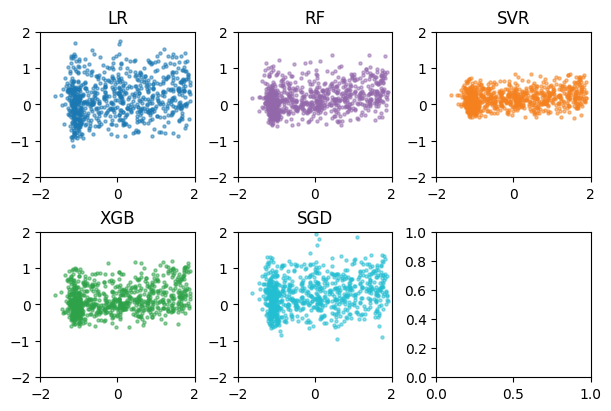

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(6, 4), constrained_layout=True)
axes = axes.flatten()

axes[0].scatter(x=y_test, y=y_pred_lr, alpha=0.5, s=5, c='#1b78b2')
axes[1].scatter(x=y_test, y=y_pred_rf, alpha=0.5, s=5, c='#9368ab')
axes[2].scatter(x=y_test, y=y_pred_svr, alpha=0.5, s=5, c='#f4801e')
axes[3].scatter(x=y_test, y=y_pred_xgb, alpha=0.5, s=5, c='#2da248')
axes[4].scatter(x=y_test, y=y_pred_sgd, alpha=0.5, s=5, c='#22bed2')

axes[0].set_title('LR')
axes[1].set_title('RF')
axes[2].set_title('SVR')
axes[3].set_title('XGB')
axes[4].set_title('SGD')

# axes[0].set_title('PCA')
# axes[0].legend_.remove()

for i in range(5):
    axes[i].set_xlim(-2, 2)
    axes[i].set_ylim(-2, 2)

fig.savefig('./Repli_Seq.GAE_Embedding.Predict_True.scatter_plot.pdf')
